In [10]:
!pip install pandas
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 30.9 MB/s  0:00:00 35.2 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 8.8 MB/s  0:00:006.6 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 15.5 MB/s  0:00:000.6 MB/s eta 0:00:01:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Raw Data

In [ ]:
df = pd.DataFrame({
    "module": [
        "conv1d",
        "gelu",
        "Einsum",
        "rfftn",
        "ifftn",
        "irfftn",
        "Others",
    ],
    "16x16": [
        26.3893,
        9.8735,
        9.6724,
        6.4864,
        6.1312,
        5.2478,
        36.1994,
    ],
    "32x32": [
        17.6255,
        13.695,
        11.8197,
        6.412,
        5.9246,
        5.9518,
        38.5714,
    ],
})

fft_df = pd.DataFrame(
    {
        "16x16 Unaccel": [6856385, 4663524],
        "16x16 Accel": [3918681, 1797893],
        "32x32 Unaccel": [30311270, 20660964],
        "32x32 Accel": [3922432, 1797893],
    },
    index=["Clock Cycles", "Instructions"],
)

conv_gemmini_df = pd.DataFrame(
    {
        "16x16 Unaccel": [1783900, 1274919],
        "16x16 Accel": [8546, 1327],
        "32x32 Unaccel": [7148014, 5099559],
        "32x32 Accel": [22853, 2382],
    },
    index=["Clock Cycles", "Instructions"],
)

conv_rvscnn_df = pd.DataFrame(
    {
        "16x16 Unaccel": [1597004, 1118241],
        "16x16 Accel": [945798, 685974],
        "32x32 Unaccel": [5873739, 4472865],
        "32x32 Accel": [3776971, 2743446],
    },
    index=["Clock Cycles", "Instructions"],
)

training_metrics_df = pd.DataFrame({
    'epoch'      : list(range(1, 16)),
    'train_h1'   : [51.496668, 31.910141, 25.11552, 20.574472, 18.324536, 16.063087, 14.613394, 14.668927, 13.210583, 12.577862, 12.760916, 12.534035, 12.006013, 11.424158, 11.095783],
    'test_16_h1' : [0.586775, 0.457827, 0.350696, 0.312273, 0.283596, 0.254185, 0.239733, 0.228477, 0.214315, 0.215284, 0.207852, 0.204088, 0.203268, 0.192498, 0.191212],
    'test_16_l2' : [0.40775, 0.291306, 0.233697, 0.221533, 0.195779, 0.178352, 0.167583, 0.162201, 0.151948, 0.151323, 0.145528, 0.14125, 0.140002, 0.130399, 0.127213],
    'test_32_h1' : [0.657383, 0.530706, 0.439169, 0.423526, 0.378755, 0.367663, 0.349103, 0.346036, 0.342781, 0.333112, 0.344912, 0.344831, 0.32849, 0.328917, 0.322749],
    'test_32_l2' : [0.388987, 0.2795, 0.225763, 0.223183, 0.197376, 0.184297, 0.17584, 0.170965, 0.167379, 0.162422, 0.164583, 0.16276, 0.153585, 0.148278, 0.143767],
})



# Model

# Speedup, etc

In [22]:
rvscnn_speedup = pd.DataFrame({
    "16x16": [
        conv_rvscnn_df.loc["Clock Cycles", "16x16 Unaccel"]
        / conv_rvscnn_df.loc["Clock Cycles", "16x16 Accel"]
    ],
    "32x32": [
        conv_rvscnn_df.loc["Clock Cycles", "32x32 Unaccel"]
        / conv_rvscnn_df.loc["Clock Cycles", "32x32 Accel"]
    ],
}, index=["Speedup"])

rvscnn_speedup.loc["Scaling Factor"] = (
    rvscnn_speedup.loc["Speedup"] ** -1
)


gemmini_speedup = pd.DataFrame({
    "16x16": [
        conv_gemmini_df.loc["Clock Cycles", "16x16 Unaccel"]
        / conv_gemmini_df.loc["Clock Cycles", "16x16 Accel"]
    ],
    "32x32": [
        conv_gemmini_df.loc["Clock Cycles", "32x32 Unaccel"]
        / conv_gemmini_df.loc["Clock Cycles", "32x32 Accel"]
    ],
}, index=["Speedup"])

gemmini_speedup.loc["Scaling Factor"] = (
    gemmini_speedup.loc["Speedup"] ** -1
)


fft_speedup = pd.DataFrame({
    "16x16": [
        fft_df.loc["Clock Cycles", "16x16 Unaccel"]
        / fft_df.loc["Clock Cycles", "16x16 Accel"]
    ],
    "32x32": [
        fft_df.loc["Clock Cycles", "32x32 Unaccel"]
        / fft_df.loc["Clock Cycles", "32x32 Accel"]
    ],
}, index=["Speedup"])

fft_speedup.loc["Scaling Factor"] = (
    fft_speedup.loc["Speedup"] ** -1
)


print("RVSCNN")
print(rvscnn_speedup.round(4))

print("\nGemmini")
print(gemmini_speedup.round(4))

print("\nFFT")
print(fft_speedup.round(4))

RVSCNN
                 16x16   32x32
Speedup         1.6885  1.5551
Scaling Factor  0.5922  0.6430

Gemmini
                   16x16     32x32
Speedup         208.7409  312.7823
Scaling Factor    0.0048    0.0032

FFT
                 16x16   32x32
Speedup         1.7497  7.7277
Scaling Factor  0.5715  0.1294


In [24]:
df_accel = df.copy()

fft_mask = df_accel["module"].isin([
    "rfftn",
    "ifftn",
    "irfftn",
])

conv_mask = df_accel["module"] == "conv1d"


# FFT + GEMMINI (16x16)
df_accel["accel 16 FFT + GEMMINI"] = df_accel["16x16"]

df_accel.loc[fft_mask, "accel 16 FFT + GEMMINI"] *= (
    fft_speedup.loc["Scaling Factor", "16x16"]
)

df_accel.loc[conv_mask, "accel 16 FFT + GEMMINI"] *= (
    gemmini_speedup.loc["Scaling Factor", "16x16"]
)


# FFT + GEMMINI (32x32)
df_accel["accel 32 FFT + GEMMINI"] = df_accel["32x32"]

df_accel.loc[fft_mask, "accel 32 FFT + GEMMINI"] *= (
    fft_speedup.loc["Scaling Factor", "32x32"]
)

df_accel.loc[conv_mask, "accel 32 FFT + GEMMINI"] *= (
    gemmini_speedup.loc["Scaling Factor", "32x32"]
)


# FFT + RVSCNN (16x16)
df_accel["accel 16 FFT + RVSCNN"] = df_accel["16x16"]

df_accel.loc[fft_mask, "accel 16 FFT + RVSCNN"] *= (
    fft_speedup.loc["Scaling Factor", "16x16"]
)

df_accel.loc[conv_mask, "accel 16 FFT + RVSCNN"] *= (
    rvscnn_speedup.loc["Scaling Factor", "16x16"]
)


# FFT + RVSCNN (32x32)
df_accel["accel 32 FFT + RVSCNN"] = df_accel["32x32"]

df_accel.loc[fft_mask, "accel 32 FFT + RVSCNN"] *= (
    fft_speedup.loc["Scaling Factor", "32x32"]
)

df_accel.loc[conv_mask, "accel 32 FFT + RVSCNN"] *= (
    rvscnn_speedup.loc["Scaling Factor", "32x32"]
)

print(df_accel)

   module    16x16    32x32  accel 16 FFT + GEMMINI  accel 32 FFT + GEMMINI  \
0  conv1d  26.3893  17.6255                0.126421                0.056351   
1    gelu   9.8735  13.6950                9.873500               13.695000   
2  Einsum   9.6724  11.8197                9.672400               11.819700   
3   rfftn   6.4864   6.4120                3.707221                0.829745   
4   ifftn   6.1312   5.9246                3.504211                0.766673   
5  irfftn   5.2478   5.9518                2.999314                0.770193   
6  Others  36.1994  38.5714               36.199400               38.571400   

   accel 16 FFT + RVSCNN  accel 32 FFT + RVSCNN  
0              15.628607              11.333667  
1               9.873500              13.695000  
2               9.672400              11.819700  
3               3.707221               0.829745  
4               3.504211               0.766673  
5               2.999314               0.770193  
6              36

# Graphs

## FFT Instructions/Cycles

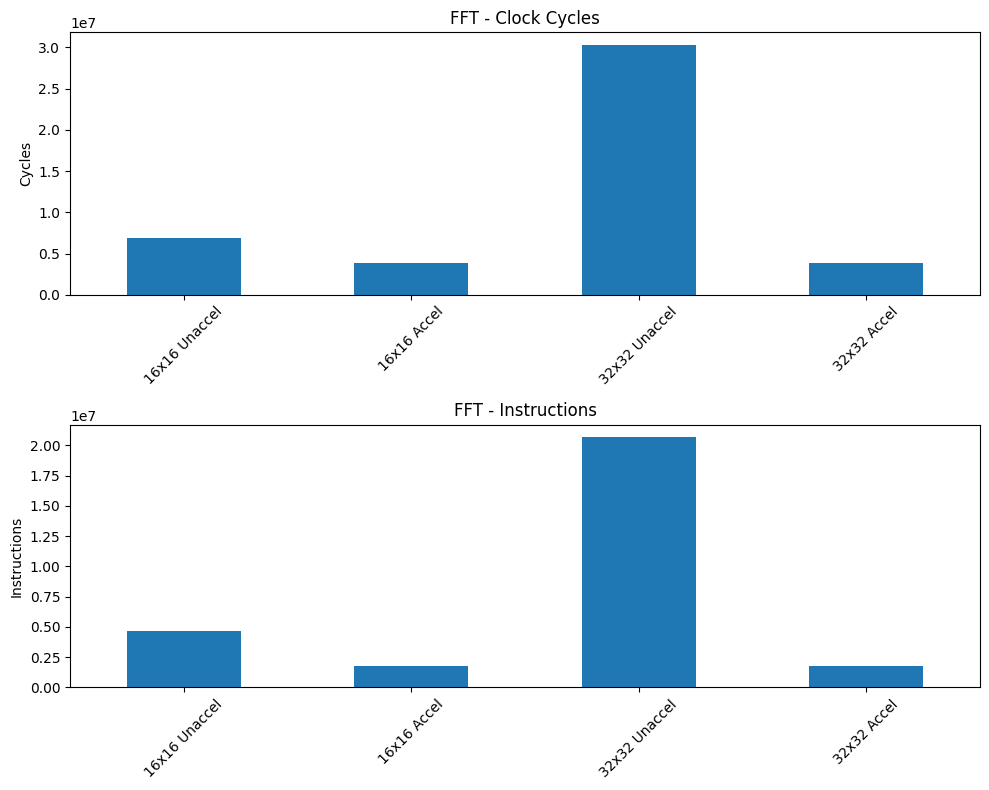

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

fft_df.loc["Clock Cycles"].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("FFT - Clock Cycles")
axes[0].set_ylabel("Cycles")
axes[0].tick_params(axis="x", rotation=45)

fft_df.loc["Instructions"].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("FFT - Instructions")
axes[1].set_ylabel("Instructions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## RVSCNN Instructions/Cycles

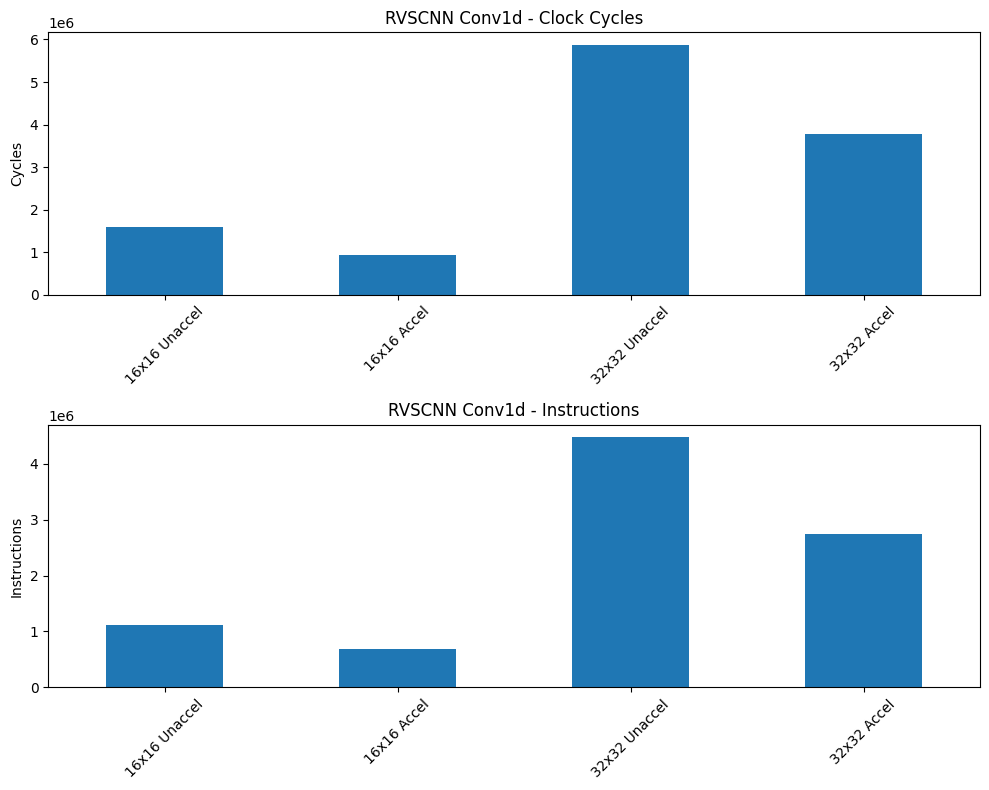

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

conv_rvscnn_df.loc["Clock Cycles"].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("RVSCNN Conv1d - Clock Cycles")
axes[0].set_ylabel("Cycles")
axes[0].tick_params(axis="x", rotation=45)

conv_rvscnn_df.loc["Instructions"].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("RVSCNN Conv1d - Instructions")
axes[1].set_ylabel("Instructions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Gemmini Instructions/Cycles

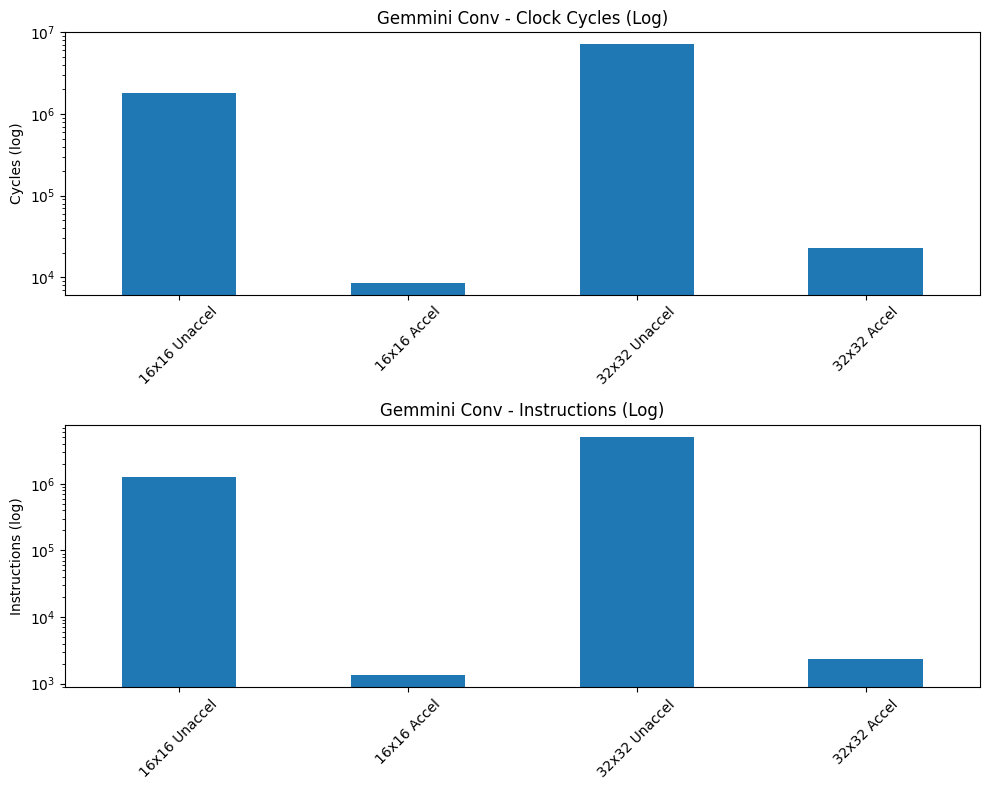

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

conv_gemmini_df.loc["Clock Cycles"].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Gemmini Conv - Clock Cycles (Log)")
axes[0].set_ylabel("Cycles (log)")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=45)

conv_gemmini_df.loc["Instructions"].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Gemmini Conv - Instructions (Log)")
axes[1].set_ylabel("Instructions (log)")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Speedup Graphs

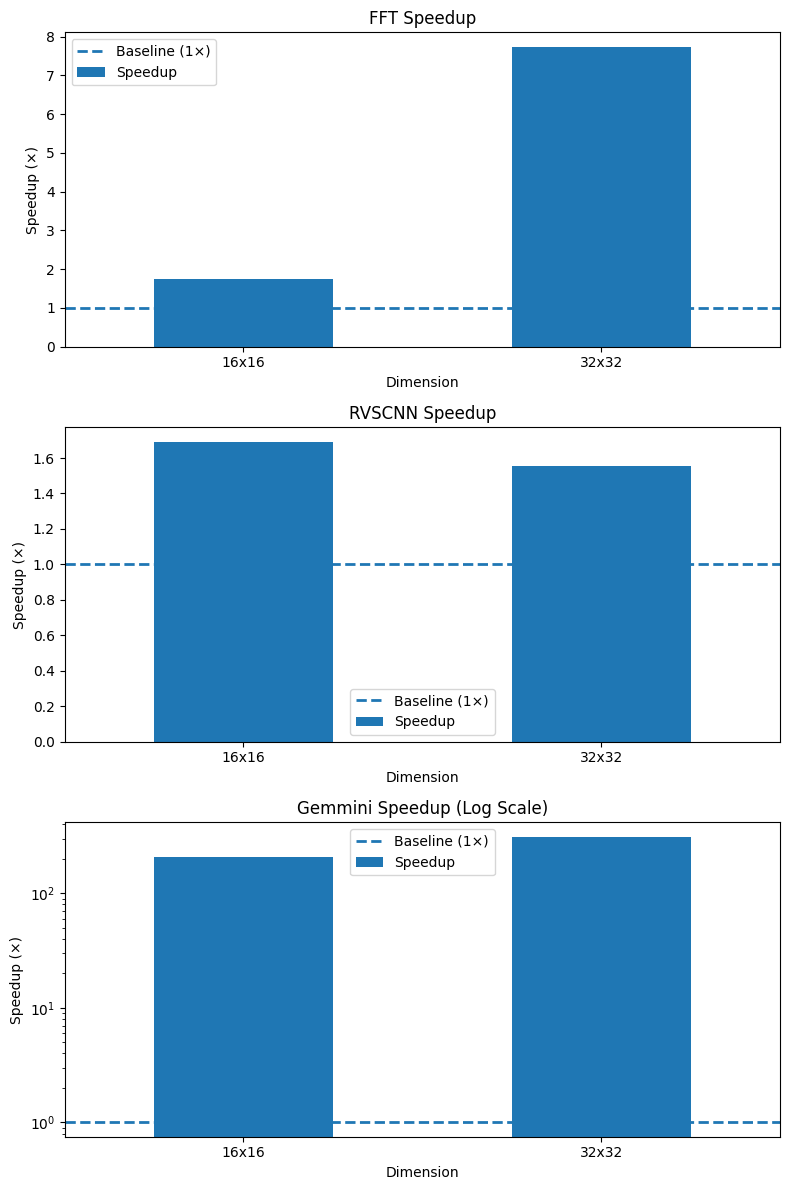

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# FFT
fft_speedup.loc["Speedup"].plot(
    kind="bar",
    ax=axes[0]
)
axes[0].axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Baseline (1×)"
)
axes[0].set_title("FFT Speedup")
axes[0].set_ylabel("Speedup (×)")
axes[0].legend()

# RVSCNN
rvscnn_speedup.loc["Speedup"].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Baseline (1×)"
)
axes[1].set_title("RVSCNN Speedup")
axes[1].set_ylabel("Speedup (×)")
axes[1].legend()

# Gemmini
gemmini_speedup.loc["Speedup"].plot(
    kind="bar",
    ax=axes[2]
)
axes[2].axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Baseline (1×)"
)
axes[2].set_yscale("log")
axes[2].set_title("Gemmini Speedup (Log Scale)")
axes[2].set_ylabel("Speedup (×)")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("Dimension")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Full FNO graphs

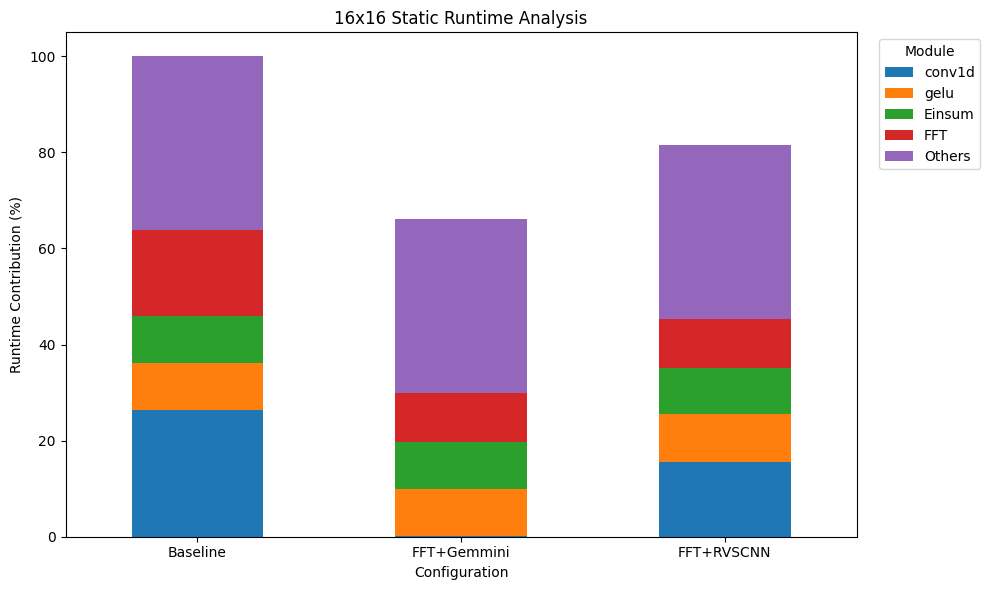

In [46]:
static_16 = pd.DataFrame({
    "Baseline": [
        df.loc[df["module"] == "conv1d", "16x16"].iloc[0],
        df.loc[df["module"] == "gelu", "16x16"].iloc[0],
        df.loc[df["module"] == "Einsum", "16x16"].iloc[0],
        df.loc[df["module"].isin(["rfftn", "ifftn", "irfftn"]), "16x16"].sum(),
        df.loc[df["module"] == "Others", "16x16"].iloc[0],
    ],
    "FFT+Gemmini": [
        df_accel.loc[df_accel["module"] == "conv1d", "accel 16 FFT + GEMMINI"].iloc[0],
        df_accel.loc[df_accel["module"] == "gelu", "accel 16 FFT + GEMMINI"].iloc[0],
        df_accel.loc[df_accel["module"] == "Einsum", "accel 16 FFT + GEMMINI"].iloc[0],
        df_accel.loc[
            df_accel["module"].isin(["rfftn", "ifftn", "irfftn"]),
            "accel 16 FFT + GEMMINI"
        ].sum(),
        df_accel.loc[df_accel["module"] == "Others", "accel 16 FFT + GEMMINI"].iloc[0],
    ],
    "FFT+RVSCNN": [
        df_accel.loc[df_accel["module"] == "conv1d", "accel 16 FFT + RVSCNN"].iloc[0],
        df_accel.loc[df_accel["module"] == "gelu", "accel 16 FFT + RVSCNN"].iloc[0],
        df_accel.loc[df_accel["module"] == "Einsum", "accel 16 FFT + RVSCNN"].iloc[0],
        df_accel.loc[
            df_accel["module"].isin(["rfftn", "ifftn", "irfftn"]),
            "accel 16 FFT + RVSCNN"
        ].sum(),
        df_accel.loc[df_accel["module"] == "Others", "accel 16 FFT + RVSCNN"].iloc[0],
    ],
}, index=["conv1d", "gelu", "Einsum", "FFT", "Others"])

ax = static_16.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("16x16 Static Runtime Analysis")
ax.set_ylabel("Runtime Contribution (%)")
ax.set_xlabel("Configuration")

plt.xticks(rotation=0)
plt.legend(title="Module", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

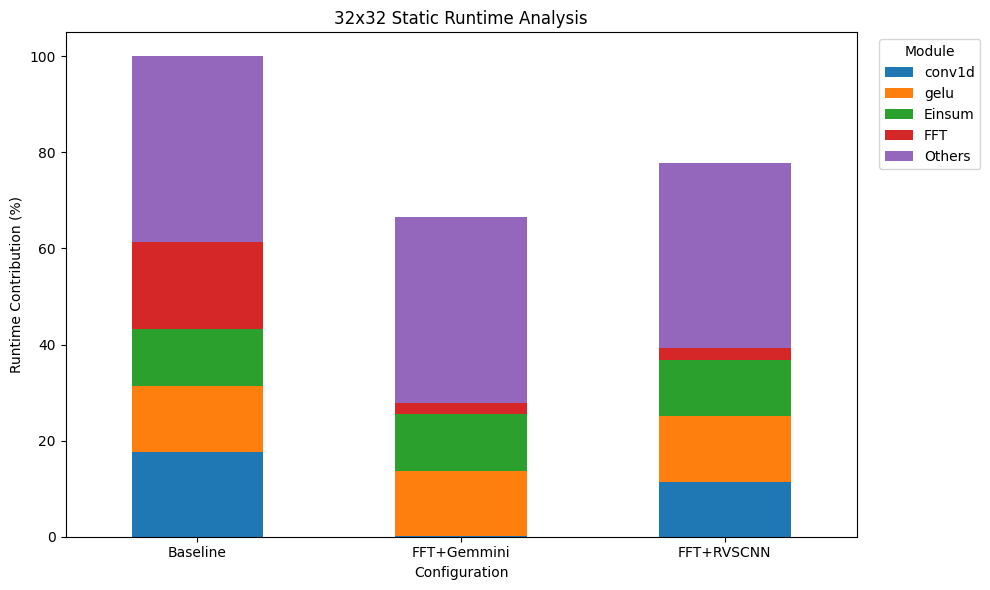

In [47]:
static_32 = pd.DataFrame({
    "Baseline": [
        df.loc[df["module"] == "conv1d", "32x32"].iloc[0],
        df.loc[df["module"] == "gelu", "32x32"].iloc[0],
        df.loc[df["module"] == "Einsum", "32x32"].iloc[0],
        df.loc[df["module"].isin(["rfftn", "ifftn", "irfftn"]), "32x32"].sum(),
        df.loc[df["module"] == "Others", "32x32"].iloc[0],
    ],
    "FFT+Gemmini": [
        df_accel.loc[df_accel["module"] == "conv1d", "accel 32 FFT + GEMMINI"].iloc[0],
        df_accel.loc[df_accel["module"] == "gelu", "accel 32 FFT + GEMMINI"].iloc[0],
        df_accel.loc[df_accel["module"] == "Einsum", "accel 32 FFT + GEMMINI"].iloc[0],
        df_accel.loc[
            df_accel["module"].isin(["rfftn", "ifftn", "irfftn"]),
            "accel 32 FFT + GEMMINI"
        ].sum(),
        df_accel.loc[df_accel["module"] == "Others", "accel 32 FFT + GEMMINI"].iloc[0],
    ],
    "FFT+RVSCNN": [
        df_accel.loc[df_accel["module"] == "conv1d", "accel 32 FFT + RVSCNN"].iloc[0],
        df_accel.loc[df_accel["module"] == "gelu", "accel 32 FFT + RVSCNN"].iloc[0],
        df_accel.loc[df_accel["module"] == "Einsum", "accel 32 FFT + RVSCNN"].iloc[0],
        df_accel.loc[
            df_accel["module"].isin(["rfftn", "ifftn", "irfftn"]),
            "accel 32 FFT + RVSCNN"
        ].sum(),
        df_accel.loc[df_accel["module"] == "Others", "accel 32 FFT + RVSCNN"].iloc[0],
    ],
}, index=["conv1d", "gelu", "Einsum", "FFT", "Others"])

ax = static_32.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("32x32 Static Runtime Analysis")
ax.set_ylabel("Runtime Contribution (%)")
ax.set_xlabel("Configuration")

plt.xticks(rotation=0)
plt.legend(title="Module", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# Speedups

In [49]:
fno_speedup = pd.Series({
    "16x16 RVSCNN":
        100 / static_16.loc[:, "FFT+RVSCNN"].sum(),

    "32x32 RVSCNN":
        100 / static_32.loc[:, "FFT+RVSCNN"].sum(),

    "16x16 Gemmini":
        100 / static_16.loc[:, "FFT+Gemmini"].sum(),

    "32x32 Gemmini":
        100 / static_32.loc[:, "FFT+Gemmini"].sum(),
})

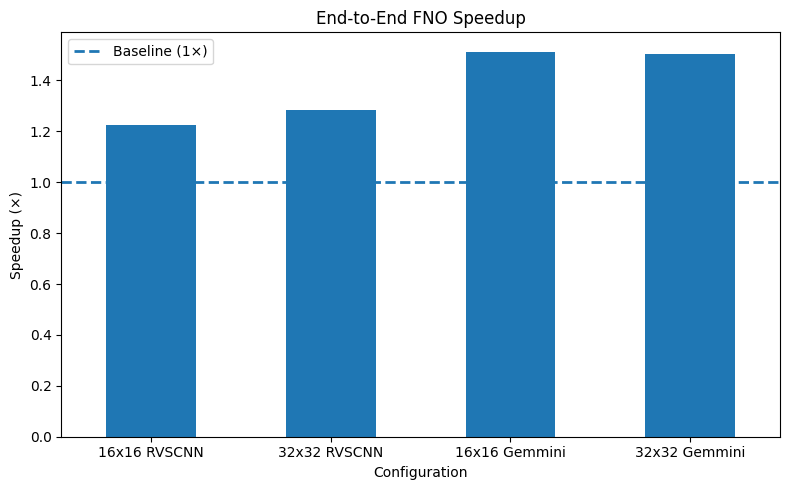

In [50]:
ax = fno_speedup.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Baseline (1×)"
)

ax.set_title("End-to-End FNO Speedup")
ax.set_ylabel("Speedup (×)")
ax.set_xlabel("Configuration")

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()